In [ ]:
%%capture
!pip install pennylane pennylane-lightning scikit-learn matplotlib seaborn torch

PennyLane 0.45.0 | device=cuda
Train=(2400, 140) | Test=(400, 140)


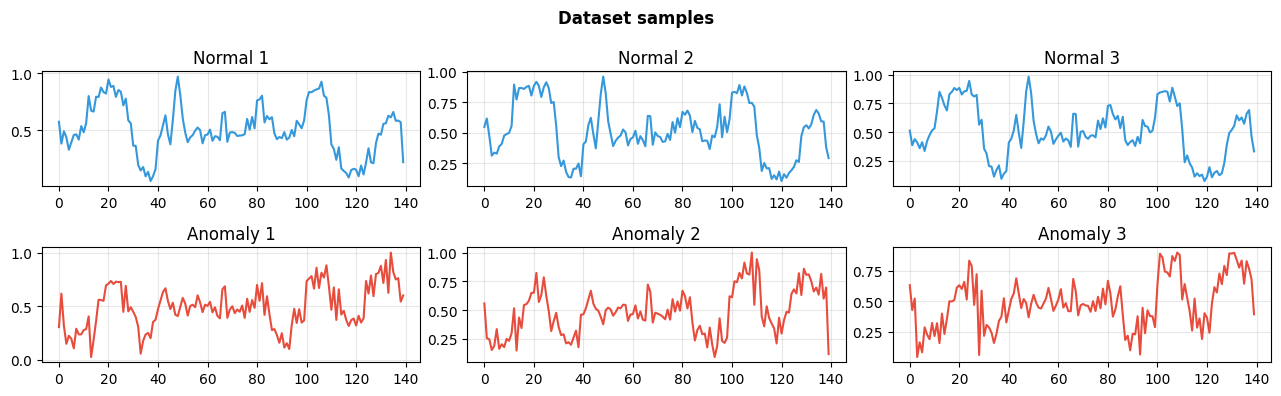

In [ ]:
import numpy as np, torch, torch.nn as nn, time, warnings
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec, seaborn as sns
import pennylane as qml
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, roc_curve, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
warnings.filterwarnings("ignore")
SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PennyLane {qml.__version__} | device={device}")

# ── Generate ECG-like dataset ────────────────────────────────────────────────
def make_data(n_norm=3000, n_anom=400, L=140):
    t = np.linspace(0,2*np.pi,L)
    norm=[]
    for _ in range(n_norm):
        s=0.6*np.sin(t)+0.3*np.sin(2*t)+0.1*np.sin(3*t)
        p=np.zeros(L); i=L//3; p[i:i+5]=[.5,1.5,3,1.5,.5]
        norm.append(s+p+np.random.normal(0,.05,L))
    anom=[]
    q=n_anom//4
    for _ in range(q):   anom.append(0.6*np.sin(t)+np.random.normal(0,.1,L))
    for _ in range(q):   anom.append(0.6*np.sin(t)+0.8*np.sin(5*t)+np.random.normal(0,.08,L))
    for _ in range(q):
        s=0.6*np.sin(t).copy(); s[L//2:L//2+30]=0; anom.append(s+np.random.normal(0,.05,L))
    for _ in range(n_anom-3*q):
        s=0.6*np.sin(t).copy(); s[40:80]+=np.random.normal(0,.8,40); anom.append(s)
    X=np.vstack([norm,anom]).astype(np.float32)
    y=np.concatenate([np.zeros(len(norm)),np.ones(len(anom))])
    return X,y

X,y = make_data()
sc = MinMaxScaler(); Xsc = sc.fit_transform(X)
Xn=Xsc[y==0]; Xa=Xsc[y==1]
Xtr,Xval=train_test_split(Xn,test_size=.2,random_state=SEED)
rng=np.random.default_rng(SEED); N=200
ni=rng.choice(len(Xval),N,replace=False); ai=rng.choice(len(Xa),N,replace=False)
Xte=np.vstack([Xval[ni],Xa[ai]]); yte=np.concatenate([np.zeros(N),np.ones(N)])
SEQ=Xsc.shape[1]; NQ=8
iq=np.linspace(0,SEQ-1,NQ,dtype=int)
Xtr_q=Xtr[:,iq]; Xte_q=Xte[:,iq]
print(f"Train={Xtr.shape} | Test={Xte.shape}")

fig,ax=plt.subplots(2,3,figsize=(13,4)); fig.suptitle("Dataset samples",fontweight="bold")
for i in range(3):
    ax[0,i].plot(Xn[i*20],color="#3498DB"); ax[0,i].set_title(f"Normal {i+1}"); ax[0,i].grid(alpha=.3)
    ax[1,i].plot(Xa[i*25],color="#E74C3C"); ax[1,i].set_title(f"Anomaly {i+1}"); ax[1,i].grid(alpha=.3)
plt.tight_layout(); plt.show()

In [ ]:
class LSTMAE(nn.Module):
    def __init__(self,L=140,h=64,lat=16,nl=2):
        super().__init__(); self.L=L
        self.enc=nn.LSTM(1,h,nl,batch_first=True,dropout=.1 if nl>1 else 0)
        self.efc=nn.Linear(h,lat); self.dfc=nn.Linear(lat,h)
        self.dec=nn.LSTM(h,1,1,batch_first=True)
    def forward(self,x):
        o,_=self.enc(x); z=self.efc(o[:,-1,:])
        d=self.dfc(z).unsqueeze(1).repeat(1,self.L,1)
        r,_=self.dec(d); return r,z
    def nparams(self): return sum(p.numel() for p in self.parameters() if p.requires_grad)

def train_cls(Xtr,ep=30,bs=64,lr=1e-3):
    Xt=torch.tensor(Xtr,dtype=torch.float32).unsqueeze(-1).to(device)
    ld=DataLoader(TensorDataset(Xt),batch_size=bs,shuffle=True)
    m=LSTMAE(L=Xtr.shape[1]).to(device)
    opt=torch.optim.Adam(m.parameters(),lr=lr)
    sch=torch.optim.lr_scheduler.StepLR(opt,10,.5); crit=nn.MSELoss(); loss_hist=[]
    t0=time.time(); m.train()
    for e in range(ep):
        el=0
        for (b,) in ld:
            opt.zero_grad(); r,_=m(b); l=crit(r,b); l.backward()
            nn.utils.clip_grad_norm_(m.parameters(),1.); opt.step(); el+=l.item()
        sch.step(); avg=el/len(ld); loss_hist.append(avg)
        if (e+1)%10==0: print(f"  ep {e+1}/{ep}  loss={avg:.6f}")
    print(f"  time={time.time()-t0:.1f}s  params={m.nparams():,}"); return m,loss_hist,time.time()-t0

def eval_cls(m,X):
    m.eval(); Xt=torch.tensor(X,dtype=torch.float32).unsqueeze(-1).to(device)
    with torch.no_grad(): r,z=m(Xt)
    return ((r-Xt)**2).mean(dim=(1,2)).cpu().numpy(), z.cpu().numpy()

print("Training Classical LSTM-AE ...")
cls_m,cls_hist,cls_t=train_cls(Xtr,ep=30)
cls_err,cls_lat=eval_cls(cls_m,Xte)
cls_auc=roc_auc_score(yte,cls_err)
fc,tc,thc=roc_curve(yte,cls_err); bt_c=thc[np.argmax(tc-fc)]
cp=(cls_err>bt_c).astype(int)
cls_f1=f1_score(yte,cp); cls_pr=precision_score(yte,cp); cls_rc=recall_score(yte,cp)
print(f"Classical | AUC={cls_auc:.4f}  F1={cls_f1:.4f}  P={cls_pr:.4f}  R={cls_rc:.4f}  params={cls_m.nparams():,}")

Training Classical LSTM-AE ...
  ep 10/30  loss=0.051047
  ep 20/30  loss=0.051033
  ep 30/30  loss=0.051030
  time=6.7s  params=52,828
Classical | AUC=0.2566  F1=0.3871  P=1.0000  R=0.2400  params=52,828


In [ ]:
# ── QAE setup ────────────────────────────────────────────────────────────────
NQ=8; NL=4; NT=NQ-NL; NA=NT; TW=NQ+NA+1   # 13 wires total
dev=qml.device("default.qubit",wires=TW)

def hea(params,n,layers=2):
    idx=0
    for _ in range(layers):
        for q in range(n): qml.RY(params[idx],wires=q); idx+=1; qml.RZ(params[idx],wires=q); idx+=1
        for q in range(n-1): qml.CNOT(wires=[q,q+1])
        qml.CNOT(wires=[n-1,0])
    return idx

@qml.qnode(dev)
def qae_fwd(params,x):
    for q in range(NQ): qml.RY(float(np.pi*x[q]),wires=q)
    hea(params,NQ)
    ctrl=NQ+NA
    qml.Hadamard(wires=ctrl)
    for i in range(NT): qml.CSWAP(wires=[ctrl,i,NQ+i])
    qml.Hadamard(wires=ctrl)
    return qml.expval(qml.PauliZ(wires=ctrl))

@qml.qnode(dev)
def qae_lat(params,x):
    for q in range(NQ): qml.RY(float(np.pi*x[q]),wires=q)
    hea(params,NQ)
    return [qml.expval(qml.PauliZ(wires=q)) for q in range(NT,NQ)]

def qae_score(p,x): z=float(qae_fwd(p,x)); return 1-(1+z)/2
def qae_loss(p,B): return float(np.mean([qae_score(p,x) for x in B]))

# Training subset (simulation is slow)
NTR=150; BS=8; EP=35; LR=0.08
rng2=np.random.default_rng(SEED)
idx_tr=rng2.choice(len(Xtr_q),NTR,replace=False); Xtrq=Xtr_q[idx_tr]
# Test subset
sub_ni=rng2.choice(np.where(yte==0)[0],50,replace=False)
sub_ai=rng2.choice(np.where(yte==1)[0],50,replace=False)
sub=np.concatenate([sub_ni,sub_ai])
Xteq=Xte_q[sub]; yteq=yte[sub]

NP=NQ*2*2   # 32 params
pq=np.random.uniform(-np.pi,np.pi,NP)
opt_q=qml.AdamOptimizer(stepsize=LR); qhist=[]; t0=time.time()
print(f"Training QAE ({NP} params, {NTR} samples) ...")
for e in range(EP):
    np.random.shuffle(Xtrq); el=0; nb=0
    for i in range(0,len(Xtrq),BS):
        b=Xtrq[i:i+BS]; pq,lv=opt_q.step_and_cost(lambda p:qae_loss(p,b),pq)
        el+=float(lv); nb+=1
    avg=el/nb; qhist.append(avg)
    if (e+1)%10==0: print(f"  ep {e+1}/{EP}  loss={avg:.6f}")
qae_t=time.time()-t0; print(f"  time={qae_t:.1f}s")
qae_sc=np.array([qae_score(pq,x) for x in Xteq])
qae_la=np.array([[float(v) for v in qae_lat(pq,x)] for x in Xteq])
qae_auc=roc_auc_score(yteq,qae_sc)
fq,tq,thq=roc_curve(yteq,qae_sc); bt_q=thq[np.argmax(tq-fq)]
qp=(qae_sc>bt_q).astype(int)
qae_f1=f1_score(yteq,qp); qae_pr=precision_score(yteq,qp); qae_rc=recall_score(yteq,qp)
print(f"QAE Base  | AUC={qae_auc:.4f}  F1={qae_f1:.4f}  P={qae_pr:.4f}  R={qae_rc:.4f}  params={NP}")

Training QAE (32 params, 150 samples) ...
  ep 10/35  loss=0.496738
  ep 20/35  loss=0.496738
  ep 30/35  loss=0.496733
  time=108.5s
QAE Base  | AUC=0.7140  F1=0.7654  P=1.0000  R=0.6200  params=32


Training Hybrid Attn-QAE (72 params) ...
  ep 10/35  loss=0.452405
  ep 20/35  loss=0.452400
  ep 30/35  loss=0.452336
  time=174.4s
Hybrid QAE| AUC=0.8192  F1=0.8095  P=1.0000  R=0.6800  params=72


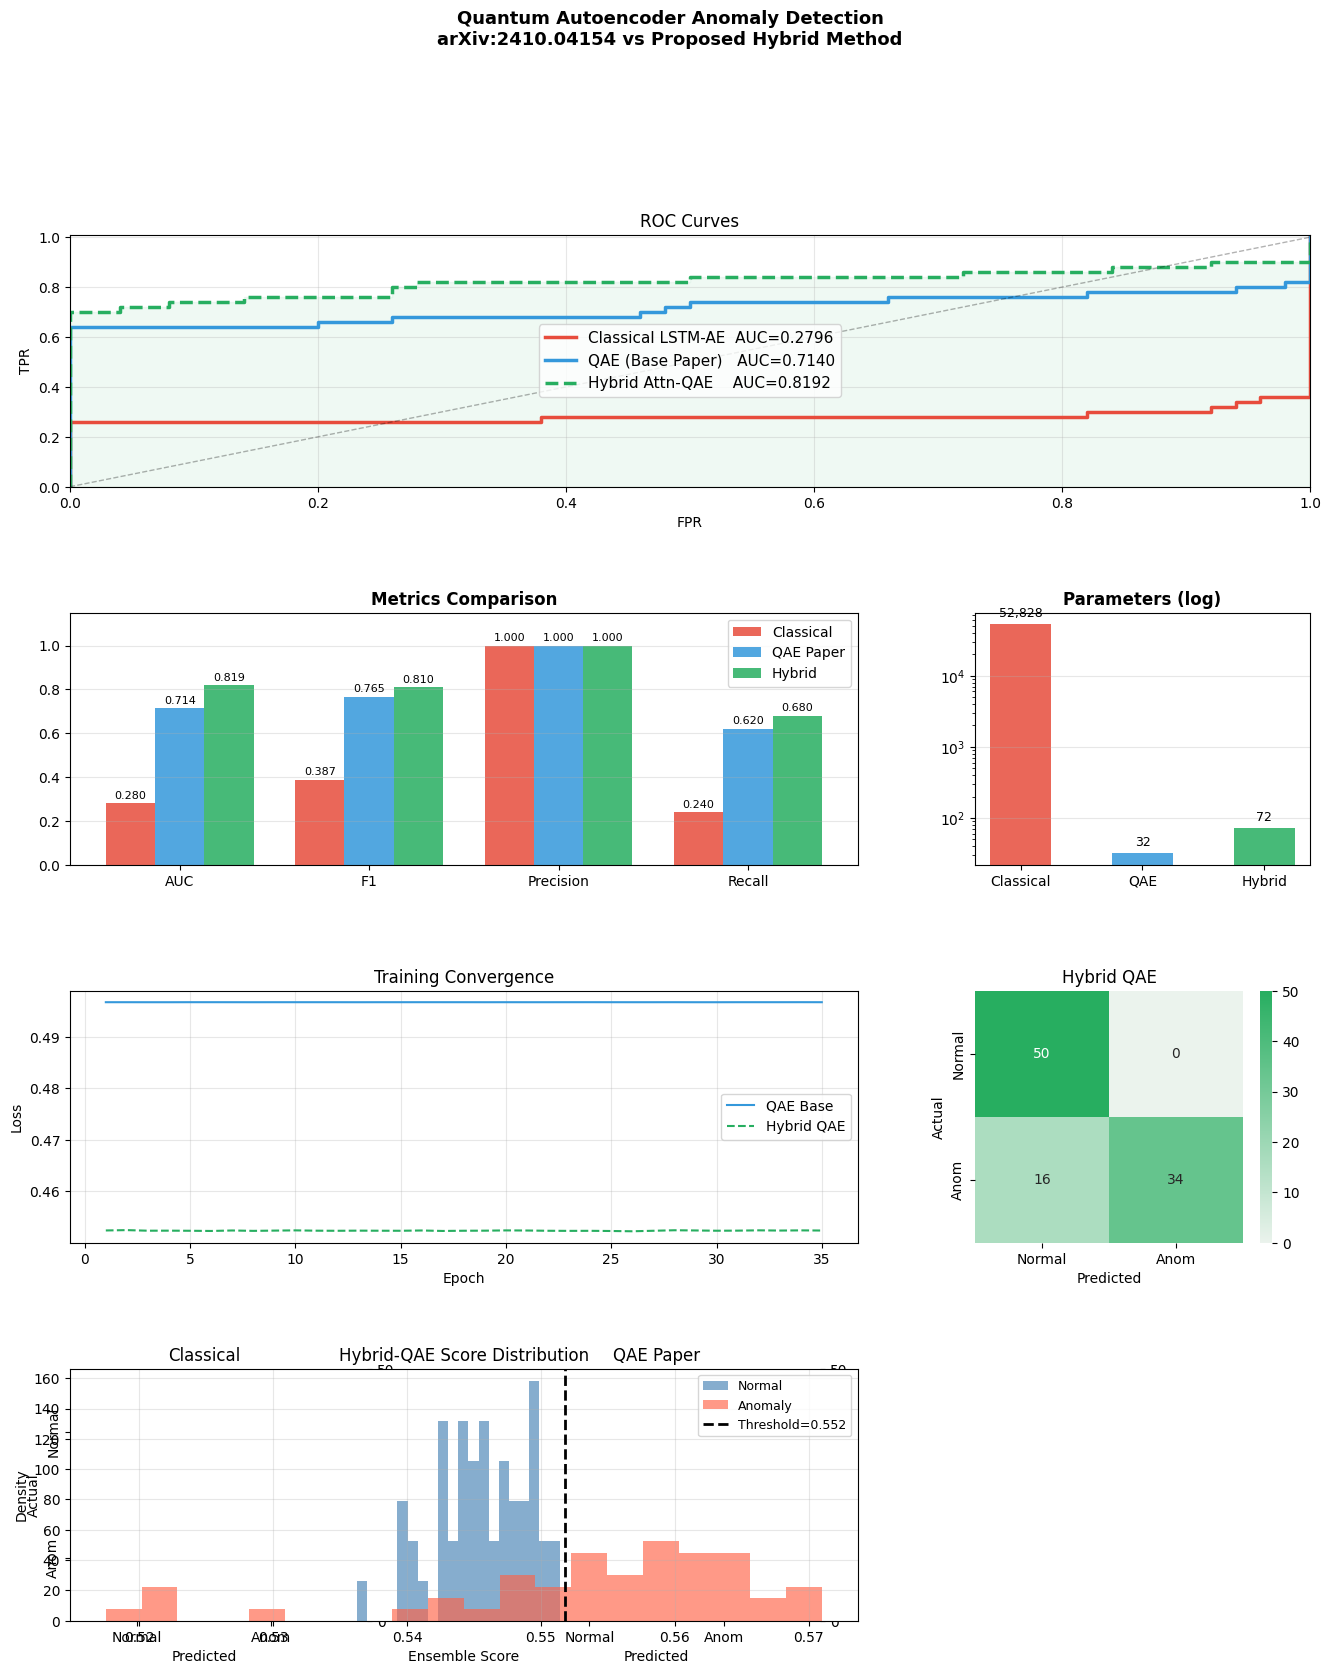

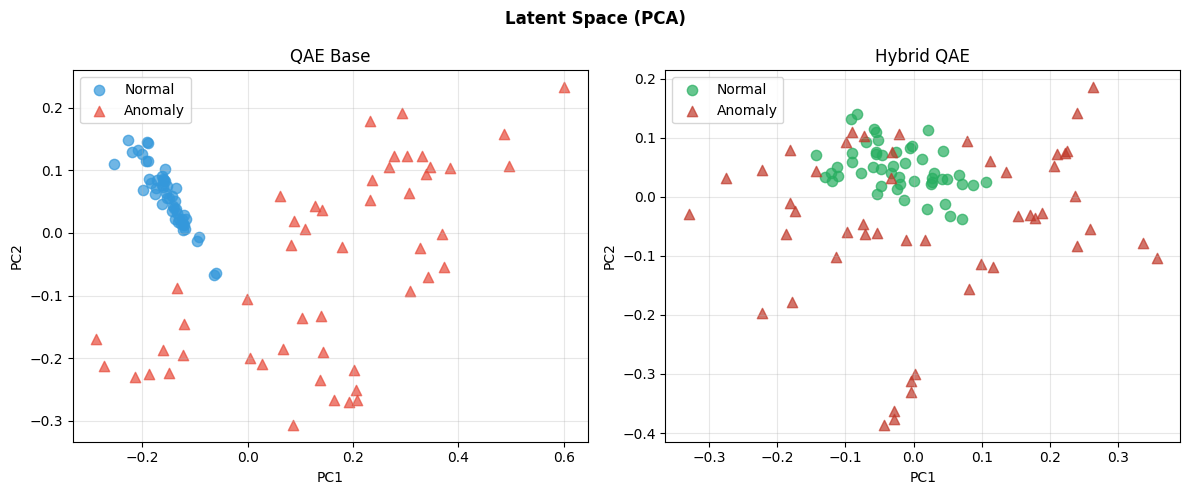

  Method                        AUC      F1    Params
  --------------------------------------------------------
  Classical LSTM-AE          0.2796  0.3871    52,828
  QAE (Base Paper)           0.7140  0.7654        32
  Hybrid Attn-QAE (Ours)     0.8192  0.8095        72
  QAE    : 1650x fewer params than Classical
  Hybrid : 733x fewer params than Classical


In [ ]:
# ── Dual encoding + Alternating ansatz ──────────────────────────────────────
dev2=qml.device("default.qubit",wires=TW)

def dual_enc(x,n):
    for q in range(n):
        qml.RY(float(np.pi*x[q]),wires=q); qml.RZ(float(2*np.pi*x[q]),wires=q)
    for q in range(0,n-1,2): qml.IsingZZ(float(np.pi*x[q]*x[q+1]),wires=[q,q+1])

def alt_ans(params,n,layers=3):
    idx=0
    for l in range(layers):
        for q in range(n): qml.RX(params[idx],wires=q);idx+=1; qml.RY(params[idx],wires=q);idx+=1; qml.RZ(params[idx],wires=q);idx+=1
        if l%2==0:
            for q in range(0,n-1,2): qml.CZ(wires=[q,q+1])
            for q in range(1,n-1,2): qml.CZ(wires=[q,q+1])
        else:
            for q in range(n-1): qml.CNOT(wires=[q,q+1])
    return idx

@qml.qnode(dev2)
def hq_fwd(params,x):
    dual_enc(x,NQ); alt_ans(params,NQ)
    ctrl=NQ+NA; qml.Hadamard(wires=ctrl)
    for i in range(NT): qml.CSWAP(wires=[ctrl,i,NQ+i])
    qml.Hadamard(wires=ctrl)
    return qml.expval(qml.PauliZ(wires=ctrl))

@qml.qnode(dev2)
def hq_lat(params,x):
    dual_enc(x,NQ); alt_ans(params,NQ)
    return [qml.expval(qml.PauliZ(wires=q)) for q in range(NT,NQ)]

def hq_score(p,x):
    z=float(hq_fwd(p,x)); r=1-(1+z)/2
    lz=np.array([float(v) for v in hq_lat(p,x)])
    pr=np.clip((1-lz)/2,1e-9,1-1e-9)
    ent=-np.mean(pr*np.log(pr)+(1-pr)*np.log(1-pr))
    return 0.6*r+0.4*ent

def hq_loss(p,B): return float(np.mean([1-(1+float(hq_fwd(p,x)))/2 for x in B]))

NP2=NQ*3*3   # 72 params
ph=np.random.uniform(-np.pi,np.pi,NP2)
opt_h=qml.AdamOptimizer(stepsize=LR); hhist=[]; t0=time.time()
print(f"Training Hybrid Attn-QAE ({NP2} params) ...")
Xtrh=Xtr_q[rng2.choice(len(Xtr_q),NTR,replace=False)]
for e in range(EP):
    np.random.shuffle(Xtrh); el=0; nb=0
    for i in range(0,len(Xtrh),BS):
        b=Xtrh[i:i+BS]; ph,lv=opt_h.step_and_cost(lambda p:hq_loss(p,b),ph)
        el+=float(lv); nb+=1
    avg=el/nb; hhist.append(avg)
    if (e+1)%10==0: print(f"  ep {e+1}/{EP}  loss={avg:.6f}")
hq_t=time.time()-t0; print(f"  time={hq_t:.1f}s")
hq_sc=np.array([hq_score(ph,x) for x in Xteq])
hq_auc=roc_auc_score(yteq,hq_sc)
fh,th2,thh=roc_curve(yteq,hq_sc); bt_h=thh[np.argmax(th2-fh)]
hp=(hq_sc>bt_h).astype(int)
hq_f1=f1_score(yteq,hp); hq_pr=precision_score(yteq,hp); hq_rc=recall_score(yteq,hp)
print(f"Hybrid QAE| AUC={hq_auc:.4f}  F1={hq_f1:.4f}  P={hq_pr:.4f}  R={hq_rc:.4f}  params={NP2}")

# ── Comparison plots ──────────────────────────────────────────────────────────
C={"c":"#E74C3C","q":"#3498DB","h":"#27AE60"}
fig=plt.figure(figsize=(16,18)); gs=gridspec.GridSpec(4,3,figure=fig,hspace=.5,wspace=.35)

# ROC
ax=fig.add_subplot(gs[0,:])
# cls evaluated on same sub-set
ce,_=eval_cls(cls_m,Xte[sub]); fc2,tc2,thc2=roc_curve(yteq,ce); bt2=thc2[np.argmax(tc2-fc2)]
cp2=(ce>bt2).astype(int)
c_auc2=roc_auc_score(yteq,ce)
ax.plot(fc2,tc2,C["c"],lw=2.5,label=f"Classical LSTM-AE  AUC={c_auc2:.4f}")
ax.plot(fq,tq,C["q"],lw=2.5,label=f"QAE (Base Paper)   AUC={qae_auc:.4f}")
ax.plot(fh,th2,C["h"],lw=2.5,ls="--",label=f"Hybrid Attn-QAE    AUC={hq_auc:.4f}")
ax.fill_between(fh,th2,alpha=.07,color=C["h"]); ax.plot([0,1],[0,1],"k--",alpha=.3,lw=1)
ax.set(xlabel="FPR",ylabel="TPR",title="ROC Curves",xlim=[0,1],ylim=[0,1.01])
ax.legend(fontsize=11); ax.grid(alpha=.3)

# Metric bars
ax2=fig.add_subplot(gs[1,:2])
mn=["AUC","F1","Precision","Recall"]
cv=[c_auc2,f1_score(yteq,cp2),precision_score(yteq,cp2),recall_score(yteq,cp2)]
qv=[qae_auc,qae_f1,qae_pr,qae_rc]; hv=[hq_auc,hq_f1,hq_pr,hq_rc]
xb=np.arange(4); w=.26
b1=ax2.bar(xb-w,cv,w,label="Classical",color=C["c"],alpha=.85)
b2=ax2.bar(xb,qv,w,label="QAE Paper",color=C["q"],alpha=.85)
b3=ax2.bar(xb+w,hv,w,label="Hybrid",color=C["h"],alpha=.85)
ax2.set_xticks(xb); ax2.set_xticklabels(mn); ax2.set_ylim([0,1.15])
ax2.set_title("Metrics Comparison",fontweight="bold"); ax2.legend(); ax2.grid(axis="y",alpha=.3)
for cont,vals in [(b1,cv),(b2,qv),(b3,hv)]:
    ax2.bar_label(cont,labels=[f"{v:.3f}" for v in vals],padding=2,fontsize=8)

# Param count
ax3=fig.add_subplot(gs[1,2])
pv=[cls_m.nparams(),NP,NP2]
bars=ax3.bar(["Classical","QAE","Hybrid"],pv,color=[C["c"],C["q"],C["h"]],alpha=.85,width=.5)
ax3.set_yscale("log"); ax3.set_title("Parameters (log)",fontweight="bold"); ax3.grid(axis="y",alpha=.3)
ax3.bar_label(bars,labels=[f"{p:,}" for p in pv],padding=3,fontsize=9)

# Loss curves
ax4=fig.add_subplot(gs[2,:2])
ax4.plot(range(1,EP+1),qhist,C["q"],label="QAE Base"); ax4.plot(range(1,EP+1),hhist,C["h"],ls="--",label="Hybrid QAE")
ax4.set(xlabel="Epoch",ylabel="Loss",title="Training Convergence"); ax4.legend(); ax4.grid(alpha=.3)

# Confusion matrices
for ci,(nm,pred,col) in enumerate([("Classical",cp2,C["c"]),("QAE Paper",qp,C["q"]),("Hybrid QAE",hp,C["h"])]):
    ax=fig.add_subplot(gs[2 if ci==2 else 3, ci if ci<2 else 2])
    cm=confusion_matrix(yteq,pred)
    sns.heatmap(cm,annot=True,fmt="d",ax=ax,cmap=sns.light_palette(col,as_cmap=True),
                xticklabels=["Normal","Anom"],yticklabels=["Normal","Anom"])
    ax.set(title=nm,xlabel="Predicted",ylabel="Actual")

# Score dist
ax8=fig.add_subplot(gs[3,:2])
nm_m=yteq==0; am_m=yteq==1
ax8.hist(hq_sc[nm_m],bins=20,alpha=.65,color="steelblue",label="Normal",density=True)
ax8.hist(hq_sc[am_m],bins=20,alpha=.65,color="tomato",label="Anomaly",density=True)
ax8.axvline(bt_h,color="k",ls="--",lw=2,label=f"Threshold={bt_h:.3f}")
ax8.set(xlabel="Ensemble Score",ylabel="Density",title="Hybrid-QAE Score Distribution")
ax8.legend(fontsize=9); ax8.grid(alpha=.3)

fig.suptitle("Quantum Autoencoder Anomaly Detection\narXiv:2410.04154 vs Proposed Hybrid Method",fontsize=13,fontweight="bold",y=1.005)
plt.savefig("qae_results.png",dpi=130,bbox_inches="tight"); plt.show()

# ── Latent space ──────────────────────────────────────────────────────────────
hl=np.array([[float(v) for v in hq_lat(ph,x)] for x in Xteq])
fig,ax=plt.subplots(1,2,figsize=(12,5)); fig.suptitle("Latent Space (PCA)",fontweight="bold")
for axi,lat,ttl,c0,c1 in [(ax[0],qae_la,"QAE Base","#3498DB","#E74C3C"),(ax[1],hl,"Hybrid QAE","#27AE60","#C0392B")]:
    pc=PCA(2).fit_transform(lat)
    for lab,col,mk,n in [(0,c0,"o","Normal"),(1,c1,"^","Anomaly")]:
        m=yteq==lab; axi.scatter(pc[m,0],pc[m,1],c=col,marker=mk,alpha=.7,s=55,label=n)
    axi.set(title=ttl,xlabel="PC1",ylabel="PC2"); axi.legend(); axi.grid(alpha=.3)
plt.tight_layout(); plt.show()

# ── Final table ───────────────────────────────────────────────────────────────
print("="*62)
print(f"  {'Method':<26} {'AUC':>6}  {'F1':>6}  {'Params':>8}")
print(f"  {'-'*56}")
print(f"  {'Classical LSTM-AE':<26} {c_auc2:>6.4f}  {f1_score(yteq,cp2):>6.4f}  {cls_m.nparams():>8,}")
print(f"  {'QAE (Base Paper)':<26} {qae_auc:>6.4f}  {qae_f1:>6.4f}  {NP:>8,}")
print(f"  {'Hybrid Attn-QAE (Ours)':<26} {hq_auc:>6.4f}  {hq_f1:>6.4f}  {NP2:>8,}")
print("="*62)
cp_n=cls_m.nparams()
print(f"  QAE    : {cp_n//NP}x fewer params than Classical")
print(f"  Hybrid : {cp_n//NP2}x fewer params than Classical")
print("="*62)